In [1]:
!pip uninstall scipy scikit-learn -y
!pip install scipy==1.13.0 scikit-learn==1.4.0 -q
!pip install monai livelossplot torchmetrics seaborn -q

Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1
Found existing installation: scikit-learn 1.3.2
Uninstalling scikit-learn-1.3.2:
  Successfully uninstalled scikit-learn-1.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [1]:
from livelossplot import PlotLosses 
from livelossplot.outputs import MatplotlibPlot
%matplotlib inline
import matplotlib.pyplot as plt
from monai.transforms import (Activations, AsDiscrete, LoadImage, EnsureChannelFirst, Resize,
                                RandZoom, RandAdjustContrast, RandGaussianNoise, RandRotate,
                                RandFlip, ToTensor, Compose, NormalizeIntensity, Lambda)
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.losses import FocalLoss
from monai.utils import set_determinism
from monai.config import print_config
import numpy as np
import os
from PIL import Image
import random
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import time
import torch
from torch.utils.data import Dataset, WeightedRandomSampler
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
import torch.nn as nn
from torchmetrics.classification import MulticlassF1Score

np.random.seed(0)
set_determinism(seed=0)
print_config()

MONAI version: 1.5.2
Numpy version: 1.26.4
Pytorch version: 2.8.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.13.0
Pillow version: 12.1.1
Tensorboard version: 2.20.0
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.23.0+cu128
tqdm version: 4.66.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: 3.0.3
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKN

In [2]:
base_dir = './MIQR-CC-Dataset/training/dataset'
phases = ['train', 'val', 'test']

data = {phase: {'images': [], 'labels': []} for phase in phases}
class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
num_class = len(class_names)
print("Classes:", class_names)

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        image_files = [
            os.path.join(class_dir, x)
            for x in os.listdir(class_dir)
            if x.lower().endswith(valid_exts)
        ]
        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    print(f"{phase.capitalize()} count =", len(data[phase]['images']))

Classes: ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
Train count = 1067
Val count = 234
Test count = 267


In [3]:
def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    RandRotate(range_x=15, prob=0.5),
    RandFlip(spatial_axis=0, prob=0.5),
    RandFlip(spatial_axis=1, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    RandAdjustContrast(prob=0.5),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.01),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

act = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)

In [4]:
class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]

labels_train = data['train']['labels']
class_counts = np.bincount(labels_train)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[l] for l in labels_train]
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(sample_weights),
    replacement=True
)

train_ds = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms)
val_ds = MedNISTDataset(data['val']['images'], data['val']['labels'], val_transforms)
test_ds = MedNISTDataset(data['test']['images'], data['test']['labels'], val_transforms)

train_loader = DataLoader(train_ds, batch_size=8, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=8, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=8, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 134
Val batches: 30


In [5]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'
torch.cuda.empty_cache()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"A usar: {device}")

model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

# Cabeça mais profunda com Dropout
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.last_channel, 512),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(512, num_class)
)

# Backbone congelado
for param in model.features.parameters():
    param.requires_grad = False

model = model.to(device)
print("Modelo pronto")
print(f"Parâmetros treináveis: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

A usar: cuda:0
Modelo pronto
Parâmetros treináveis: 657,924


In [6]:
def train_model(train_dl, val_dl, model, loss_function, optimizer, epochs, name):
    early_stopping_patience = 10
    epochs_without_improvement = 0
    liveloss = PlotLosses(outputs=[MatplotlibPlot(figpath=f"{name}.png")])
    best_metric = -1
    best_metric_epoch = -1
    metric_values = list()

    f1_metric = MulticlassF1Score(num_classes=num_class, average='macro').to(device)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    for epoch in range(epochs):
        logs = {}
        model.train()
        running_loss = 0.0
        running_corrects = 0.0
        y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
        y_train = torch.tensor([], dtype=torch.long, device=device)

        for inputs, labels in train_dl:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.detach() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            y_pred_train = torch.cat([y_pred_train, outputs], dim=0)
            y_train = torch.cat([y_train, labels], dim=0)

        epoch_loss = running_loss / len(train_dl.dataset)
        epoch_acc = running_corrects.float() / len(train_dl.dataset)
        pred_train_labels = y_pred_train.argmax(dim=1)
        f1_train_value = f1_metric(pred_train_labels, y_train)

        logs['loss'] = epoch_loss.item()
        logs['accuracy'] = epoch_acc.item()
        logs['F1'] = f1_train_value.item()

        model.eval()
        running_loss = 0.0
        running_corrects = 0.0
        y_pred = torch.tensor([], dtype=torch.float32, device=device)
        y = torch.tensor([], dtype=torch.long, device=device)

        with torch.no_grad():
            for val_images, val_labels in val_dl:
                val_images = val_images.to(device)
                val_labels = val_labels.to(device)
                outputs = model(val_images)
                loss = loss_function(outputs, val_labels)
                running_loss += loss.detach() * val_images.size(0)
                _, preds = torch.max(outputs, 1)
                running_corrects += torch.sum(preds == val_labels.data)
                y_pred = torch.cat([y_pred, outputs], dim=0)
                y = torch.cat([y, val_labels], dim=0)

            epoch_loss = running_loss / len(val_dl.dataset)
            epoch_acc = running_corrects.float() / len(val_dl.dataset)
            logs['val_loss'] = epoch_loss.item()
            logs['val_accuracy'] = epoch_acc.item()

            pred_labels = y_pred.argmax(dim=1)
            f1_score_value = f1_metric(pred_labels, y)
            logs['val_F1'] = f1_score_value.item()

            y_onehot = [to_onehot(i) for i in decollate_batch(y, detach=False)]
            y_pred_act = [act(i) for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            metric_values.append(result)

            if f1_score_value > best_metric:
                best_metric = f1_score_value
                best_metric_epoch = epoch + 1
                best_train_f1 = f1_train_value.item()
                torch.save(model.state_dict(), name)
                print('saved new best metric model')
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= early_stopping_patience:
                print(
                    f"Early stopping at epoch {epoch + 1} \n"
                    f" Best Val F1: {best_metric:.4f} \n"
                    f" Best Train F1: {best_train_f1:.4f} \n"
                    f" current Val F1: {f1_score_value:.4f} \n"
                    f" current Train F1: {f1_train_value:.4f} \n"
                    f" Best epoch: {best_metric_epoch} \n"
                )
                break
            print(
                f"epoch {epoch + 1} | AUC: {result:.4f}"
                f" | F1 train: {f1_train_value:.4f}"
                f" | F1 val: {f1_score_value:.4f}"
                f" | best F1: {best_metric:.4f}"
                f" | epoch: {best_metric_epoch}"
            )

        logs['val_AUC'] = result
        liveloss.update(logs)
        liveloss.send()
        scheduler.step()

    print(f"train completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")

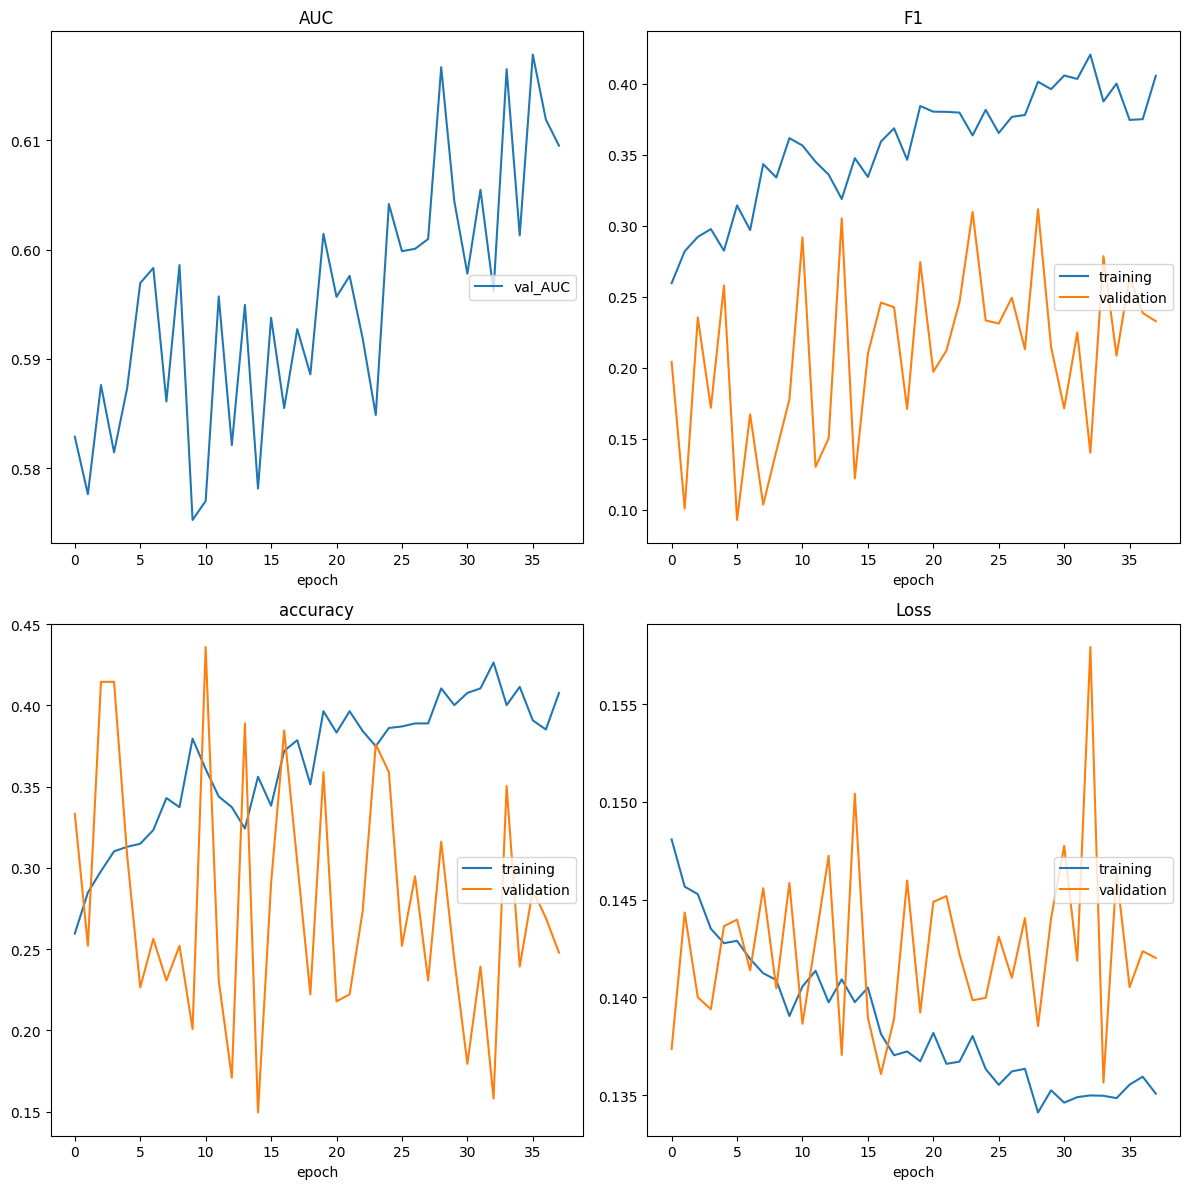

Early stopping at epoch 39 
 Best Val F1: 0.3116 
 Best Train F1: 0.4014 
 current Val F1: 0.2764 
 current Train F1: 0.3991 
 Best epoch: 29 

train completed, best_metric: 0.3116 at epoch: 29
Treino concluído em 2384.1 segundos


In [7]:
model_name = 'mobilenet_v2_teresa_v5.pth'
auc_metric = ROCAUCMetric()

EPOCHS = 60
LR = 1e-4

loss_function = FocalLoss(to_onehot_y=True)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    LR,
    weight_decay=1e-3
)

starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function, optimizer, EPOCHS, model_name)
endtime = time.perf_counter()
print(f"Treino concluído em {endtime - starttime:.1f} segundos")

F1 Score no teste: 0.4531
               precision    recall  f1-score   support

Biliary_Leaks     0.3333    0.7059    0.4528        17
    Lithiasis     0.5492    0.5447    0.5469       123
       Normal     0.4839    0.3488    0.4054        43
    Stricture     0.4231    0.3929    0.4074        84

     accuracy                         0.4757       267
    macro avg     0.4474    0.4981    0.4531       267
 weighted avg     0.4852    0.4757    0.4743       267



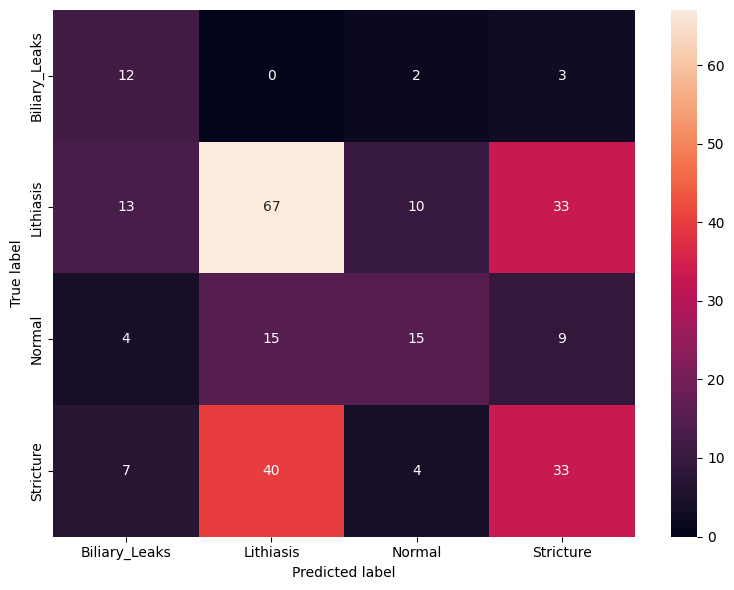

In [8]:
def evaluate_model(test_dl, model):
    model.load_state_dict(torch.load(model_name, map_location=device))
    model.eval()
    predictions = []
    actual_values = []

    with torch.no_grad():
        for inputs, labels in test_dl:
            inputs = inputs.to(device)
            yprev = model(inputs)
            yprev = yprev.detach().cpu().numpy()
            actual = labels.cpu().numpy()
            yprev = np.argmax(yprev, axis=1)
            actual = actual.reshape((len(actual), 1))
            yprev = yprev.reshape((len(yprev), 1))
            predictions.append(yprev)
            actual_values.append(actual)

    predictions, actual_values = np.vstack(predictions), np.vstack(actual_values)
    f1 = f1_score(actual_values, predictions, average='macro')
    print(f"F1 Score no teste: {f1:.4f}")
    print(classification_report(actual_values, predictions, 
                                target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(actual_values, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, xticklabels=class_names, 
                yticklabels=class_names, fmt='g')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

    return actual_values, predictions

actual_values, predictions = evaluate_model(test_loader, model)